In [11]:
from torch import nn
import torch
import math
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch import Tensor
import numpy as np
import random
from os import listdir

from src.Dataset import dataset_TES
from src.ParametricTSNE import train_ptsne, plot_results
from src.GaussianMixture import gaussian_mixture

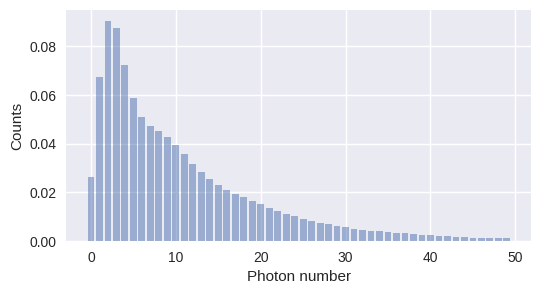

In [12]:
weights_u = [0.0003478958721172963, 0.0003456379713743067, 0.0003744276723215052, 2.7560595871623853e-07, 
           5.1048808392493295e-18, 0.28842984940480537, 0.9999999999999999, 0.4483193456686096, 
           0.34462236788026945, 0.42745454124885873, 6.426683431466243e-24, 3.0632312612371824e-29, 0.4770426849308018]
#weights = 8*[1]
weights_t = [0.07051088775512344, 0.21031270568057314, 0.38445365365055423, 0.6780434874139336, 0.6001082447024342, 0.9999999999999999, 0.629191619746778, 1.1954682934335052e-17, 0.9999999799606453, 0.9999999999649708]

data_train, data_test, expected_prob = dataset_TES(weights = weights_t,
                                                path_random_index = None,
                                                # path_test = r'/home/nicolasdc/files/Photon-Number-Classification/src/Datasets/TES/NIST test/',
                                                # path_train = r'/home/nicolasdc/files/Photon-Number-Classification/src/Datasets/TES\NIST train/',
                                                signal_size = 8192,
                                                interval = [0,350],
                                                order_dB = False,
                                                plot_expected = True,
                                                n_photon_number = 50)

In [13]:
def weights_init(m: nn.Module) -> None:
    if isinstance(m, (nn.Linear,)):
        nn.init.kaiming_normal_(m.weight.data)
        m.bias.data.fill_(0.01)
    elif isinstance(m, (nn.BatchNorm1d,)):
        m.weight.data.fill_(1.0)
        m.bias.data.fill_(0)

In [14]:
def size_conv(L_in,
              padding : int = 0,
              dilation : int = 1,
              kernel_size : int = 5,
              stride : int = 2):

    return (((L_in + 2*padding - dilation*(kernel_size - 1)) - 1) / stride) + 1

def size_deconv(L_in,
                padding : int = 0,
                dilation : int = 1,
                kernel_size : int = 5,
                stride : int = 2,
                output_padding : int = 0):
    
    return (L_in - 1)*stride - 2*padding + dilation*(kernel_size - 1) + output_padding + 1

In [15]:
class Network1(nn.Module):

    def __init__(self, dim_input, dim_emb=2):
        super().__init__()

        size_conv1 = size_conv(dim_input, 
                                padding = 0,
                                kernel_size = 4,
                                stride = 2)
        size_conv2 = size_conv(size_conv1,
                                padding = 0,
                                kernel_size = 4,
                                stride = 2)
        size_conv3 = size_conv(size_conv2,
                                padding = 0,
                                kernel_size = 4,
                                stride = 2)

        size_deconv1 = size_deconv(size_conv3,
                                    padding = 0,
                                    kernel_size = 4,
                                    stride = 2,
                                    output_padding = 0)
        size_deconv2 = size_deconv(size_deconv1,
                                    padding = 0,
                                    kernel_size = 4,
                                    stride = 2,
                                    output_padding = 0)
        size_deconv3 = size_deconv(size_deconv2,
                                    padding = 0,
                                    kernel_size = 4,
                                    stride = 2,
                                    output_padding = 0)

        print(size_conv1, size_conv2, size_conv3)
        print(size_deconv1, size_deconv2, size_deconv3)

        filter_e = 12
        filter_d = 12

        self.dim_input = dim_input
        self.dim_emb = dim_emb
        
        self.encoder1 = nn.Sequential(
            nn.Conv1d(1, filter_e, kernel_size = 4, stride = 2, padding = 0),
            nn.BatchNorm1d(filter_e),
            #nn.Dropout1d(0.25),
            nn.ReLU(),
            nn.Conv1d(filter_e, filter_e, kernel_size = 4, stride = 2, padding = 0),
            nn.BatchNorm1d(filter_e),
            #nn.Dropout1d(0.25),
            nn.ReLU(),
            nn.Conv1d(filter_e, filter_e, kernel_size = 4, stride = 2, padding = 0),
            nn.ReLU(),

            nn.Flatten(start_dim=1),
        )

        self.encoder2 = nn.Sequential(
            nn.Linear(int(filter_e*size_conv3), 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, dim_emb),
            #nn.Sigmoid()
        )


        self.decoder1 = nn.Sequential(
            nn.Linear(dim_emb, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, int(filter_d*size_conv3)),
            nn.ReLU()
        )

        self.decoder2 = nn.Sequential(

            nn.Unflatten(dim=1, unflattened_size=(filter_d, int(size_conv3))),

            nn.ConvTranspose1d(filter_d, filter_d, kernel_size = 4, stride = 2, padding = 0, output_padding = 0),
            nn.BatchNorm1d(filter_d),
            nn.ReLU(),
            nn.ConvTranspose1d(filter_d, filter_d, kernel_size = 4, stride = 2, padding = 0, output_padding = 0),
            nn.BatchNorm1d(filter_d),
            nn.ReLU(),
            nn.ConvTranspose1d(filter_d, 1, kernel_size = 4, stride = 2, padding = 0, output_padding = 0)
        )

        self.apply(weights_init)

    def forward(self, x, 
                encode = False, 
                decode = False,
                both = False):
        if encode:
            x = x.view(-1,1,self.dim_input)
            x = self.encoder1(x)
            return self.encoder2(x).view(-1,self.dim_emb)
        elif both:
            x = x.view(-1,1,self.dim_input)
            x = self.encoder1(x)
            encoder_ = self.encoder2(x)
            decoder_ = self.decoder1(encoder_)
            decoder_ = self.decoder2(decoder_)
            return encoder_.view(-1,self.dim_emb), decoder_.view(-1,self.dim_input)
        elif decode:
            x = self.decoder1(x)
            return self.decoder2(x).view(-1,self.dim_input)

In [16]:
class Network(nn.Module):

    def __init__(self, dim_input, dim_emb=1, layer_size = 300, n_layer = 4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(dim_input, layer_size)
        )
        
        for l in range(n_layer):
            self.encoder.append(nn.BatchNorm1d(layer_size))
            self.encoder.append(nn.ReLU())
            self.encoder.append(nn.Linear(layer_size, layer_size))

        self.encoder.append(nn.BatchNorm1d(layer_size))
        self.encoder.append(nn.ReLU())
        self.encoder.append(nn.Linear(layer_size, dim_emb))

        self.decoder = nn.Sequential(
            nn.Linear(dim_emb, layer_size)
        )

        for l in range(n_layer):
            self.decoder.append(nn.BatchNorm1d(layer_size))
            self.decoder.append(nn.ReLU())
            self.decoder.append(nn.Linear(layer_size, layer_size))

        self.decoder.append(nn.BatchNorm1d(layer_size))
        self.decoder.append(nn.ReLU())
        self.decoder.append(nn.Linear(layer_size, dim_input))

        self.apply(weights_init)

    def forward(self, x, 
                encode = False, 
                decode = False,
                both = False):
        if encode:
            return self.encoder(x)
        elif both:
            encoder_ = self.encoder(x)
            decoder_ = self.decoder(encoder_)
            return encoder_, decoder_
        elif decode:
            return self.decoder(x)


In [17]:
params = {
        'network' : {
            'dim_input' : 350,
            'dim_emb' : 1
            },
        'data' : {
            'weights' : weights_t
            },
        'tSNE' : {
            'perplexity' : 10,
            'early_exaggeration' : 4,
            'early_exaggeration_constant' : 12,
            'dist_func_name' : 'euc',
            'bin_search_tol' : 1e-4,
            'bin_search_max_iter' : 300,
            'min_allowed_sig_sq' : 0,
            'max_allowed_sig_sq' : 1000,
            },
        'training' : {
            'n_epochs' : 1000,
            'learning_rate' : 0.005,#0.01
            'alpha_pos' : 2,
            'alpha_l1' : 0,
            'alpha_KL' : 1,
            'size_gauss' : 4,
            'batch_size' : 1000,
            'n_cluster' : 30
            }
        }

In [18]:
model = Network(**params['network'])

In [26]:
alpha = [1]
gauss = [3,4,5]
perplex = list(np.linspace(2,400,10))#[10, 20, 50, 70, 100, 200, 300, 400]
lr = [0.001, 0.0007, 0.0005, 0.0003, 0.0001]


#for p in perplex:
try:
    #l = random.choice(lr)
    #a = random.choice(alpha)
    #g = random.choice(gauss)
    #p = random.choice(perplex)
    params = {
    'network' : {
        'dim_input' : 350,
        'dim_emb' : 1
        },
    'data' : {
        'weights' : weights_t
        },
    'tSNE' : {
        'perplexity' : 10,
        'early_exaggeration' : 4,
        'early_exaggeration_constant' : 12,
        'dist_func_name' : 'euc',
        'bin_search_tol' : 1e-5,
        'bin_search_max_iter' : 300,
        'min_allowed_sig_sq' : 0,
        'max_allowed_sig_sq' : 1000,
        },
    'training' : {
        'n_epochs' : 1000,
        'learning_rate' : 0.001,
        'alpha_pos' : 0,
        'alpha_l1' : 0,
        'alpha_KL' : 1,
        'size_gauss' : 4,
        'batch_size' : 3_000,
        'n_cluster' : 30
        }
    }

    model = Network(**params['network'])

    train_ptsne(X_high = data_train[:30_000],#data_train[:30_000],
                # Model
                model = model,
                # Params
                params = params,
                # Training
                **params['training'],
                # Files
                model_name = f'test 6',
                dev = 'cuda',
                save_dir_path = 'src/Models/Sweep 1D thermal',
                # t-SNE
                **params['tSNE'],
                # Display load
                verbose = True)
except Exception as ex:
    print(ex)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [07:58<00:00,  2.09it/s]

Model saved as src/Models/Sweep 1D thermal -> test 6


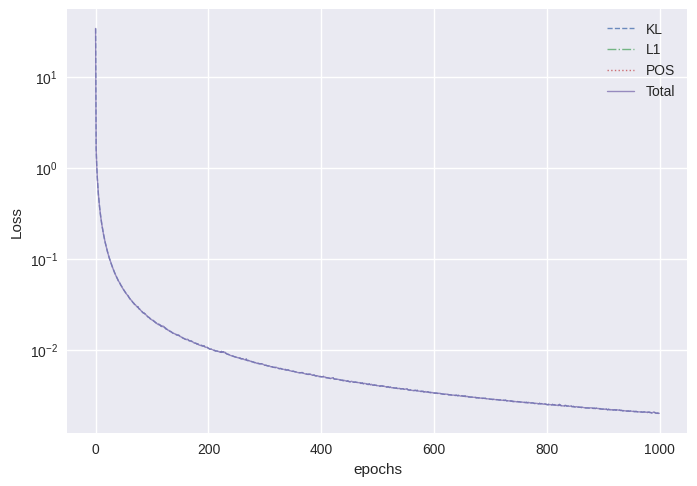

network
   dim_input : 350
   dim_emb : 1
data
   weights : [0.07051088775512344, 0.21031270568057314, 0.38445365365055423, 0.6780434874139336, 0.6001082447024342, 0.9999999999999999, 0.629191619746778, 1.1954682934335052e-17, 0.9999999799606453, 0.9999999999649708]
tSNE
   perplexity : 10
   early_exaggeration : 4
   early_exaggeration_constant : 12
   dist_func_name : euc
   bin_search_tol : 1e-05
   bin_search_max_iter : 300
   min_allowed_sig_sq : 0
   max_allowed_sig_sq : 1000
training
   n_epochs : 1000
   learning_rate : 0.001
   alpha_pos : 0
   alpha_l1 : 0
   alpha_KL : 1
   size_gauss : 4
   batch_size : 3000
   n_cluster : 30


In [27]:

# for file_ in listdir('src/Models/Sweep'):
#     if file_[:5] == 'model':
#         model_name = file_[6:-3]
plot_results(model,
            folder_name = 'src/Models/Sweep 1D thermal',
            model_name = 'test 6')

test 6


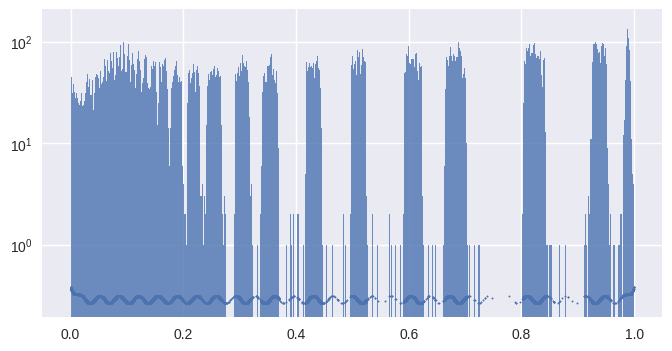

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
import os



#for file_ in next(os.walk('src/Models/Sweep perp ([8]*1)'))[1]:
#     #if file_[:5] == 'model':
try:
    folder_name = 'src/Models/Sweep 1D thermal'
    model_name = 'test 6'#file_
    n_cluster = 30
    X_ = np.linspace(0,1,1000)


    print(model_name)

    train_dl = torch.from_numpy(data_test).view(-1, 350).float()
    train_dl = (train_dl - train_dl.min()) / (train_dl.max() - train_dl.min())
    folder_name = f'{folder_name}/{model_name}'
    model.load_state_dict(torch.load(f'{folder_name}/model.pt'))
    model = model.to(torch.device('cpu'))
    model.eval()

    emb, reconst = model(train_dl, both=True)
    emb_ = (emb - emb.min()) / (emb.max() - emb.min())

    means = torch.linspace(0,1,n_cluster)
    std = 1 / (2*n_cluster)
    emb_net = emb_[:,0].view(-1,1)
    desired_dist = 1.5 - torch.sum(torch.exp(- 0.5 * ((emb_net - means) / std) ** 2), dim=1)

    with plt.style.context("seaborn-v0_8"):

        plt.figure(figsize=(8,4))
        emb_ = emb_.detach().numpy()
        plt.hist(emb_, alpha=0.8, bins=2000)
        #plt.scatter(emb_[:,0], emb_[:,1], alpha=0.05, s=1)
        plt.scatter(emb_[:,0], desired_dist.detach().numpy(), s=1)
        plt.yscale('log')
        plt.show()
except:
    pass

In [ ]:
cond = (emb_ <0.4).flatten()
train_dl = train_dl[cond]

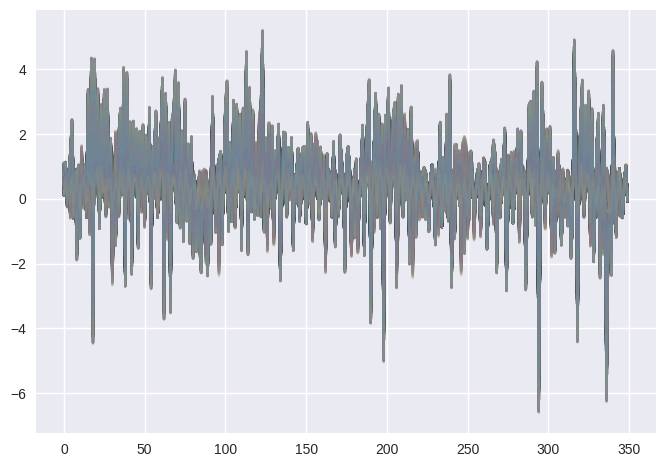

In [ ]:
with plt.style.context("seaborn-v0_8"):

    plt.plot(reconst.detach().numpy()[::10,:].T, alpha=0.08)
    plt.show()

/home/nicolasdc/anaconda3/envs/ML/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


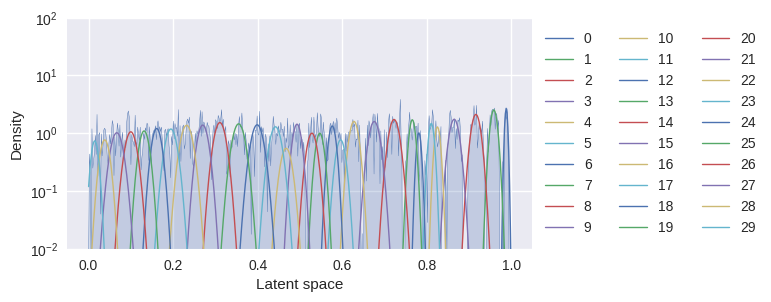

In [ ]:
name_method = 'AUTO'
#condition = emb.detach().numpy().flatten() > 0.6
gm = gaussian_mixture(emb.detach().numpy(),
                      data_test,
                      number_cluster = 30,
                      cluster_iter = 5,
                      tol = 1e-3,
                      means_init = None,#np.linspace(0,1,25).reshape(-1,1),#get_means(name_method, path_results),
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust=0.001,
                plot_gaussians=True)

In [ ]:
gm.remove_clusters([4,6,8,10,12])

In [ ]:
means=gm.cluster_means

In [ ]:
gm.plot_confidence_1d(expected_prob=expected_prob,use_uniform=True, size_zone=1000)

NameError: name 'trapezoid' is not defined